In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q transformers timm

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split

from transformers import SegformerForSemanticSegmentation

from tqdm import tqdm

In [27]:
DATA_DIR = "/content/drive/MyDrive/Mammogram_Project"

X = np.load(os.path.join(DATA_DIR,"density_roi_x.npy"))
Y = np.load(os.path.join(DATA_DIR,"density_roi_y.npy"))
D = np.load(os.path.join(DATA_DIR,"density_labels.npy"))

print(X.shape)
print(Y.shape)
print(D.shape)

(1696, 224, 224)
(1696, 224, 224)
(1696,)


In [28]:
from sklearn.model_selection import train_test_split
import numpy as np

# First split: 80% train, 20% temp
X_train, X_temp, Y_train, Y_temp, D_train, D_temp = train_test_split(
    X,
    Y,
    D,
    test_size=0.20,
    random_state=42,
    stratify=D
)

# Second split: temp -> 10% val, 10% test
X_val, X_test, Y_val, Y_test, D_val, D_test = train_test_split(
    X_temp,
    Y_temp,
    D_temp,
    test_size=0.50,
    random_state=42,
    stratify=D_temp
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

Train: (1356, 224, 224)
Val  : (170, 224, 224)
Test : (170, 224, 224)


In [29]:
X_train = X_train.astype(np.float32)/255.
X_val   = X_val.astype(np.float32)/255.
X_test  = X_test.astype(np.float32)/255.

Y_train = Y_train.astype(np.float32)
Y_val   = Y_val.astype(np.float32)
Y_test  = Y_test.astype(np.float32)

In [30]:
X_train = np.repeat(X_train[...,None],3,-1)
X_val   = np.repeat(X_val[...,None],3,-1)
X_test  = np.repeat(X_test[...,None],3,-1)

Y_train = np.expand_dims(Y_train,1)
Y_val   = np.expand_dims(Y_val,1)
Y_test  = np.expand_dims(Y_test,1)

In [31]:
import torch
from torch.utils.data import Dataset, DataLoader

In [32]:
from torch.utils.data import Dataset

class MammogramDataset(Dataset):

    def __init__(self, images, masks, labels):
        self.images = images
        self.masks = masks
        self.labels = labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):

        image = self.images[idx]

        if image.ndim == 2:
            image = np.repeat(image[..., None], 3, axis=-1)

        image = torch.tensor(
            image.transpose(2, 0, 1),
            dtype=torch.float32
        )

        mask = torch.tensor(
            self.masks[idx],
            dtype=torch.float32
        )

        density = torch.tensor(
            self.labels[idx],
            dtype=torch.long
        )

        return image, mask, density

In [33]:
train_dataset = MammogramDataset(
    X_train,
    Y_train,
    D_train
)

val_dataset = MammogramDataset(
    X_val,
    Y_val,
    D_val
)

test_dataset = MammogramDataset(
    X_test,
    Y_test,
    D_test
)

In [34]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

In [35]:
print(X_train.shape)
print(X_train[0].shape)

(1356, 224, 224, 3)
(224, 224, 3)


In [37]:
import torch
import torch.nn as nn
from transformers import SegformerForSemanticSegmentation

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [39]:
model = SegformerForSemanticSegmentation.from_pretrained(
    "nvidia/segformer-b0-finetuned-ade-512-512",
    num_labels=1,
    ignore_mismatched_sizes=True
)

model = model.to(device)

config.json:   0%|          | 0.00/6.88k [00:00<?, ?B/s]

[transformers] You passed `num_labels=1` which is incompatible to the `id2label` map of length `150`.


model.safetensors: reconstructing file:   0%|          |  0.00B / 15.0MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

[transformers] SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b0-finetuned-ade-512-512
Key                           | Status   |                                                                                                     
------------------------------+----------+-----------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150, 256, 1, 1]) vs model:torch.Size([1, 256, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch - ckpt: torch.Size([150]) vs model:torch.Size([1])                      

Notes:
- MISMATCH:	ckpt weights were loaded, but they did not match the original empty weight shapes.


In [40]:
print(model)

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (stages): ModuleList(
      (0): SegformerStage(
        (patch_embeddings): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (blocks): ModuleList(
          (0): SegformerLayer(
            (layernorm_before): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
            (attention): SegformerAttention(
              (q_proj): Linear(in_features=32, out_features=32, bias=True)
              (k_proj): Linear(in_features=32, out_features=32, bias=True)
              (v_proj): Linear(in_features=32, out_features=32, bias=True)
              (o_proj): Linear(in_features=32, out_features=32, bias=True)
              (sequence_reduction): SegformerSequenceReduction(
                (sequence_reduction): Conv2d(32, 32, kernel_size=(8, 8), stride=(8, 8))
        

In [41]:
import torch
import torch.nn as nn

class DiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

    def forward(self, logits, targets):

        probs = torch.sigmoid(logits)

        probs = probs.view(-1)
        targets = targets.view(-1)

        intersection = (probs * targets).sum()

        dice = (2. * intersection + 1e-6) / (
            probs.sum() + targets.sum() + 1e-6
        )

        return 1 - dice

In [42]:
class BCEDiceLoss(nn.Module):

    def __init__(self):
        super().__init__()

        self.bce = nn.BCEWithLogitsLoss()
        self.dice = DiceLoss()

    def forward(self, logits, targets):

        return self.bce(logits, targets) + self.dice(logits, targets)

In [43]:
criterion = BCEDiceLoss()

In [44]:
from torch.optim import AdamW

optimizer = AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

In [45]:
from torch.optim.lr_scheduler import CosineAnnealingLR

scheduler = CosineAnnealingLR(
    optimizer,
    T_max=50
)

In [46]:
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

In [47]:
best_dice = 0

patience = 10
counter = 0

EPOCHS = 50

In [48]:
SAVE_PATH = "/content/drive/MyDrive/Mammogram_Project/SegFormer_B0_best.pth"

In [49]:
import torch

def calculate_metrics(outputs, masks, threshold=0.5, smooth=1e-6):

    probs = torch.sigmoid(outputs)
    preds = (probs > threshold).float()

    preds = preds.view(-1)
    masks = masks.view(-1)

    TP = (preds * masks).sum()
    FP = (preds * (1 - masks)).sum()
    FN = ((1 - preds) * masks).sum()
    TN = ((1 - preds) * (1 - masks)).sum()

    accuracy = (TP + TN + smooth) / (TP + TN + FP + FN + smooth)

    precision = (TP + smooth) / (TP + FP + smooth)

    recall = (TP + smooth) / (TP + FN + smooth)

    f1 = (2 * precision * recall + smooth) / (
        precision + recall + smooth
    )

    iou = (TP + smooth) / (TP + FP + FN + smooth)

    dice = (2 * TP + smooth) / (
        2 * TP + FP + FN + smooth
    )

    return (
        accuracy.item(),
        precision.item(),
        recall.item(),
        f1.item(),
        iou.item(),
        dice.item()
    )

In [50]:
outputs = model(pixel_values=images)

logits = outputs.logits

logits = torch.nn.functional.interpolate(
    logits,
    size=masks.shape[-2:],   # (224,224)
    mode="bilinear",
    align_corners=False
)

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

In [51]:
print(device)
print(next(model.parameters()).device)

cuda
cuda:0


In [52]:
images, masks, density = next(iter(train_loader))

print(images.device)
print(masks.device)

cpu
cpu


In [53]:
images = images.to(device)
masks = masks.to(device)

In [54]:
outputs = model(pixel_values=images)

In [55]:

print(images.device)
print(masks.device)

cuda:0
cuda:0


In [56]:
print(outputs.logits.shape)

torch.Size([8, 1, 56, 56])


In [57]:
from tqdm import tqdm
import torch.nn.functional as F
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

best_dice = 0
patience = 10
counter = 0

EPOCHS = 50

for epoch in range(EPOCHS):

    ########################################
    # TRAIN
    ########################################

    model.train()

    train_loss = 0
    train_acc = 0
    train_prec = 0
    train_rec = 0
    train_f1 = 0
    train_iou = 0
    train_dice = 0

    for images, masks, density in tqdm(train_loader):

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        with autocast("cuda"):

            outputs = model(pixel_values=images)

            logits = outputs.logits

            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = criterion(logits, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

        acc, prec, rec, f1, iou, dice = calculate_metrics(
            logits,
            masks
        )

        train_acc += acc
        train_prec += prec
        train_rec += rec
        train_f1 += f1
        train_iou += iou
        train_dice += dice

    scheduler.step()

    train_loss /= len(train_loader)
    train_acc /= len(train_loader)
    train_prec /= len(train_loader)
    train_rec /= len(train_loader)
    train_f1 /= len(train_loader)
    train_iou /= len(train_loader)
    train_dice /= len(train_loader)

    ########################################
    # VALIDATION
    ########################################

    model.eval()

    val_loss = 0
    val_acc = 0
    val_prec = 0
    val_rec = 0
    val_f1 = 0
    val_iou = 0
    val_dice = 0

    with torch.no_grad():

        for images, masks, density in tqdm(val_loader):

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images)

            logits = outputs.logits

            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            loss = criterion(logits, masks)

            val_loss += loss.item()

            acc, prec, rec, f1, iou, dice = calculate_metrics(
                logits,
                masks
            )

            val_acc += acc
            val_prec += prec
            val_rec += rec
            val_f1 += f1
            val_iou += iou
            val_dice += dice

    val_loss /= len(val_loader)
    val_acc /= len(val_loader)
    val_prec /= len(val_loader)
    val_rec /= len(val_loader)
    val_f1 /= len(val_loader)
    val_iou /= len(val_loader)
    val_dice /= len(val_loader)

    ########################################
    # SAVE BEST MODEL
    ########################################

    if val_dice > best_dice:

        best_dice = val_dice
        counter = 0

        torch.save(model.state_dict(), SAVE_PATH)

    else:

        counter += 1

    ########################################
    # PRINT
    ########################################

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")

    print(f"Train Loss : {train_loss:.4f} | Val Loss : {val_loss:.4f}")
    print(f"Train Dice : {train_dice:.4f} | Val Dice : {val_dice:.4f}")
    print(f"Train IoU  : {train_iou:.4f} | Val IoU  : {val_iou:.4f}")
    print(f"Train Acc  : {train_acc:.4f} | Val Acc  : {val_acc:.4f}")
    print(f"Train Prec : {train_prec:.4f} | Val Prec : {val_prec:.4f}")
    print(f"Train Rec  : {train_rec:.4f} | Val Rec  : {val_rec:.4f}")
    print(f"Train F1   : {train_f1:.4f} | Val F1   : {val_f1:.4f}")

    if counter >= patience:

        print("\nEarly stopping triggered!")
        break

print("\nTraining Finished!")
print("Best Validation Dice :", best_dice)

100%|██████████| 22/22 [00:01<00:00, 11.39it/s]



Epoch [1/50]
Train Loss : 1.0631 | Val Loss : 0.7383
Train Dice : 0.6030 | Val Dice : 0.7608
Train IoU  : 0.4517 | Val IoU  : 0.6160
Train Acc  : 0.8661 | Val Acc  : 0.9566
Train Prec : 0.4800 | Val Prec : 0.6685
Train Rec  : 0.9132 | Val Rec  : 0.8884
Train F1   : 0.6030 | Val F1   : 0.7608


100%|██████████| 22/22 [00:00<00:00, 30.33it/s]



Epoch [2/50]
Train Loss : 0.5694 | Val Loss : 0.4375
Train Dice : 0.7984 | Val Dice : 0.8245
Train IoU  : 0.6662 | Val IoU  : 0.7029
Train Acc  : 0.9654 | Val Acc  : 0.9723
Train Prec : 0.7415 | Val Prec : 0.8245
Train Rec  : 0.8762 | Val Rec  : 0.8279
Train F1   : 0.7984 | Val F1   : 0.8245


100%|██████████| 22/22 [00:00<00:00, 22.05it/s]


...


Epoch [41/50]
Train Loss : 0.0932 | Val Loss : 0.2308
Train Dice : 0.9426 | Val Dice : 0.8689
Train IoU  : 0.8916 | Val IoU  : 0.7692
Train Acc  : 0.9910 | Val Acc  : 0.9793
Train Prec : 0.9408 | Val Prec : 0.8677
Train Rec  : 0.9446 | Val Rec  : 0.8724
Train F1   : 0.9426 | Val F1   : 0.8689


100%|██████████| 22/22 [00:00<00:00, 29.47it/s]



Epoch [42/50]
Train Loss : 0.0912 | Val Loss : 0.2306
Train Dice : 0.9439 | Val Dice : 0.8691
Train IoU  : 0.8939 | Val IoU  : 0.7696
Train Acc  : 0.9912 | Val Acc  : 0.9793
Train Prec : 0.9422 | Val Prec : 0.8660
Train Rec  : 0.9457 | Val Rec  : 0.8747
Train F1   : 0.9439 | Val F1   : 0.8691


100%|██████████| 22/22 [00:00<00:00, 29.51it/s]


Epoch [43/50]
Train Loss : 0.0911 | Val Loss : 0.2303
Train Dice : 0.9437 | Val Dice : 0.8694
Train IoU  : 0.8935 | Val IoU  : 0.7700
Train Acc  : 0.9912 | Val Acc  : 0.9793
Train Prec : 0.9426 | Val Prec : 0.8672
Train Rec  : 0.9450 | Val Rec  : 0.8739
Train F1   : 0.9437 | Val F1   : 0.8694

Early stopping triggered!

Training Finished!
Best Validation Dice : 0.8702068464322523


In [58]:
model.load_state_dict(torch.load(SAVE_PATH))
model.eval()

SegformerForSemanticSegmentation(
  (segformer): SegformerModel(
    (stages): ModuleList(
      (0): SegformerStage(
        (patch_embeddings): SegformerOverlapPatchEmbeddings(
          (proj): Conv2d(3, 32, kernel_size=(7, 7), stride=(4, 4), padding=(3, 3))
          (layer_norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        )
        (blocks): ModuleList(
          (0): SegformerLayer(
            (layernorm_before): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
            (attention): SegformerAttention(
              (q_proj): Linear(in_features=32, out_features=32, bias=True)
              (k_proj): Linear(in_features=32, out_features=32, bias=True)
              (v_proj): Linear(in_features=32, out_features=32, bias=True)
              (o_proj): Linear(in_features=32, out_features=32, bias=True)
              (sequence_reduction): SegformerSequenceReduction(
                (sequence_reduction): Conv2d(32, 32, kernel_size=(8, 8), stride=(8, 8))
        

In [59]:
import torch.nn.functional as F

test_loss = 0

test_acc = 0
test_prec = 0
test_rec = 0
test_f1 = 0
test_iou = 0
test_dice = 0

all_preds = []
all_masks = []
all_density = []

with torch.no_grad():

    for images, masks, density in test_loader:

        images = images.to(device)
        masks = masks.to(device)

        outputs = model(pixel_values=images)

        logits = outputs.logits

        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False
        )

        loss = criterion(logits, masks)

        test_loss += loss.item()

        acc, prec, rec, f1, iou, dice = calculate_metrics(
            logits,
            masks
        )

        test_acc += acc
        test_prec += prec
        test_rec += rec
        test_f1 += f1
        test_iou += iou
        test_dice += dice

        preds = (torch.sigmoid(logits) > 0.5).float()

        all_preds.append(preds.cpu())
        all_masks.append(masks.cpu())
        all_density.append(density)

test_loss /= len(test_loader)
test_acc /= len(test_loader)
test_prec /= len(test_loader)
test_rec /= len(test_loader)
test_f1 /= len(test_loader)
test_iou /= len(test_loader)
test_dice /= len(test_loader)

In [60]:
import pandas as pd

metrics = pd.DataFrame({

    "Dataset":["Test"],

    "Loss":[test_loss],

    "Dice":[test_dice],

    "IoU":[test_iou],

    "Accuracy":[test_acc],

    "Precision":[test_prec],

    "Recall":[test_rec],

    "F1":[test_f1]

})

metrics

,Dataset,Loss,Dice,IoU,Accuracy,Precision,Recall,F1
0,Test,0.230067,0.866653,0.765765,0.97883,0.859592,0.876735,0.866653


In [61]:
all_preds = torch.cat(all_preds)
all_masks = torch.cat(all_masks)
all_density = torch.cat(all_density).numpy()

In [62]:
rows = []

for d in sorted(np.unique(all_density)):

    idx = np.where(all_density == d)[0]

    preds = all_preds[idx]
    masks = all_masks[idx]

    acc, prec, rec, f1, iou, dice = calculate_metrics(
        preds,
        masks
    )

    rows.append({

        "Density": int(d),
        "Samples": len(idx),
        "Dice": round(dice,4),
        "IoU": round(iou,4),
        "Accuracy": round(acc,4),
        "Precision": round(prec,4),
        "Recall": round(rec,4),
        "F1": round(f1,4)

    })

density_metrics = pd.DataFrame(rows)

density_metrics

,Density,Samples,Dice,IoU,Accuracy,Precision,Recall,F1
0,1,34,0.8586,0.7523,0.9821,0.8640,0.8533,0.8586
1,2,76,0.8663,0.7642,0.9775,0.8724,0.8604,0.8663
2,3,45,0.8665,0.7644,0.9788,0.8295,0.9069,0.8665
3,4,15,0.8567,0.7493,0.9739,0.8438,0.8700,0.8567


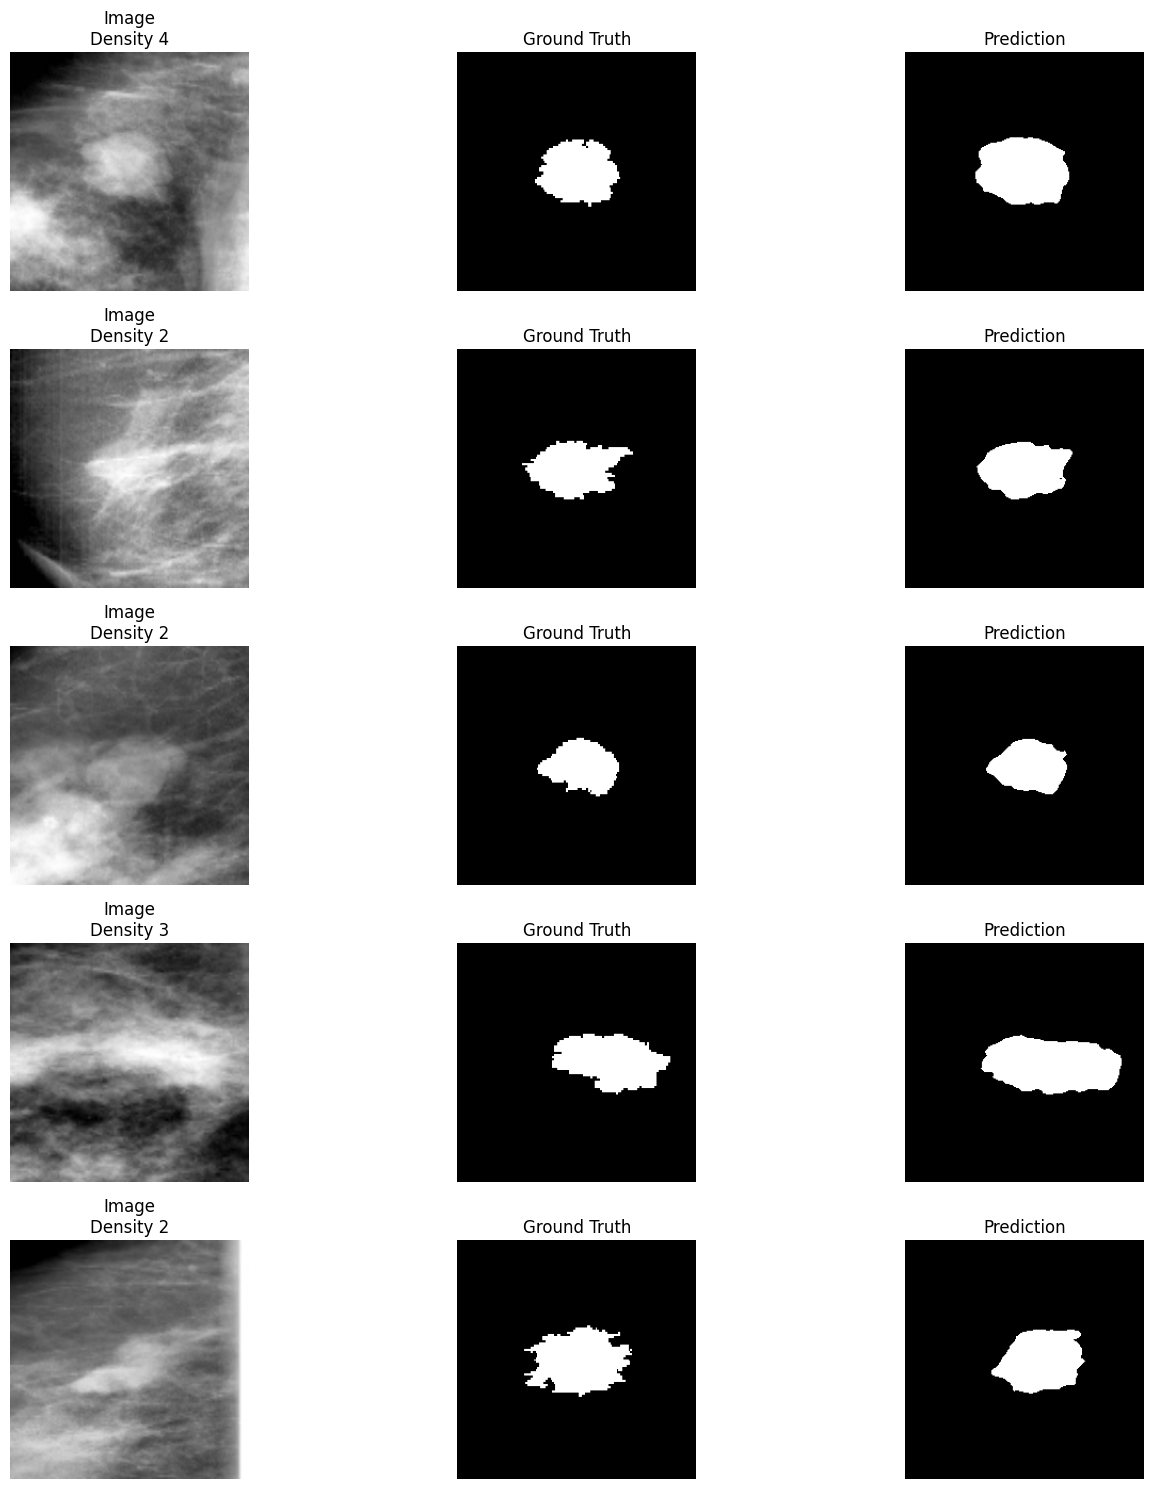

In [63]:
import matplotlib.pyplot as plt
import random

indices = random.sample(range(len(all_preds)),5)

plt.figure(figsize=(15,15))

for i,idx in enumerate(indices):

    plt.subplot(5,3,3*i+1)
    plt.imshow(X_test[idx][:,:,0], cmap="gray")
    plt.title(f"Image\nDensity {D_test[idx]}")
    plt.axis("off")

    plt.subplot(5,3,3*i+2)
    plt.imshow(all_masks[idx][0], cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(5,3,3*i+3)
    plt.imshow(all_preds[idx][0], cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [64]:
train_metrics = {
    "Loss": train_loss,
    "Dice": train_dice,
    "IoU": train_iou,
    "Accuracy": train_acc,
    "Precision": train_prec,
    "Recall": train_rec,
    "F1": train_f1
}

val_metrics = {
    "Loss": val_loss,
    "Dice": val_dice,
    "IoU": val_iou,
    "Accuracy": val_acc,
    "Precision": val_prec,
    "Recall": val_rec,
    "F1": val_f1
}

In [65]:
overall_metrics = pd.DataFrame({
    "Dataset": ["Train", "Validation", "Test"],
    "Loss": [
        train_metrics["Loss"],
        val_metrics["Loss"],
        test_loss
    ],
    "Dice": [
        train_metrics["Dice"],
        val_metrics["Dice"],
        test_dice
    ],
    "IoU": [
        train_metrics["IoU"],
        val_metrics["IoU"],
        test_iou
    ],
    "Accuracy": [
        train_metrics["Accuracy"],
        val_metrics["Accuracy"],
        test_acc
    ],
    "Precision": [
        train_metrics["Precision"],
        val_metrics["Precision"],
        test_prec
    ],
    "Recall": [
        train_metrics["Recall"],
        val_metrics["Recall"],
        test_rec
    ],
    "F1": [
        train_metrics["F1"],
        val_metrics["F1"],
        test_f1
    ]
})

overall_metrics

,Dataset,Loss,Dice,IoU,Accuracy,Precision,Recall,F1
0,Train,0.091141,0.943694,0.893547,0.991246,0.942561,0.945001,0.943694
1,Validation,0.230327,0.869352,0.769965,0.979334,0.867171,0.873927,0.869352
2,Test,0.230067,0.866653,0.765765,0.978830,0.859592,0.876735,0.866653


In [66]:
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F

def density_metrics(loader, model):

    model.eval()

    preds_all = []
    masks_all = []
    density_all = []

    with torch.no_grad():

        for images, masks, density in loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(pixel_values=images)

            logits = outputs.logits

            logits = F.interpolate(
                logits,
                size=masks.shape[-2:],
                mode="bilinear",
                align_corners=False
            )

            preds = (torch.sigmoid(logits) > 0.5).float()

            preds_all.append(preds.cpu())
            masks_all.append(masks.cpu())
            density_all.append(density)

    preds_all = torch.cat(preds_all)
    masks_all = torch.cat(masks_all)
    density_all = torch.cat(density_all).numpy()

    result = {}

    for d in sorted(np.unique(density_all)):

        idx = np.where(density_all == d)[0]

        acc, prec, rec, f1, iou, dice = calculate_metrics(
            preds_all[idx],
            masks_all[idx]
        )

        result[d] = {
            "Dice": dice,
            "IoU": iou
        }

    return result

In [67]:
train_density = density_metrics(train_loader, model)
val_density   = density_metrics(val_loader, model)
test_density  = density_metrics(test_loader, model)

In [68]:
rows = []

for d in [1,2,3,4]:

    rows.append({

        "Density": d,

        "Train Dice": round(train_density[d]["Dice"],4),
        "Val Dice": round(val_density[d]["Dice"],4),
        "Test Dice": round(test_density[d]["Dice"],4),

        "Train IoU": round(train_density[d]["IoU"],4),
        "Val IoU": round(val_density[d]["IoU"],4),
        "Test IoU": round(test_density[d]["IoU"],4),

    })

density_table = pd.DataFrame(rows)

density_table

,Density,Train Dice,Val Dice,Test Dice,Train IoU,Val IoU,Test IoU
0,1,0.9496,0.8857,0.8586,0.9041,0.7948,0.7523
1,2,0.9491,0.8779,0.8663,0.9031,0.7824,0.7642
2,3,0.9458,0.8617,0.8665,0.8971,0.7571,0.7644
3,4,0.9434,0.8547,0.8567,0.8928,0.7463,0.7493
